# HealDA Global Data Assimilation

Producing a global weather analysis from satellite and in-situ observations.

This example demonstrates how to use the HealDA data assimilation model to produce
a global weather analysis on a HEALPix grid from sparse in-situ (conventional) and
satellite radiance observations sourced from the NOAA UFS replay archive.
Three runs are compared: conventional observations only, satellite observations only,
and both combined to illustrate the impact of each observation type.

In this example you will learn:

- How to load and initialise the HealDA data assimilation model
- Fetching UFS conventional and satellite observation DataFrames
- Running the model with different observation combinations
- Comparing the assimilated global fields against ERA5 data

## Set Up
This example requires the following components:

- Assimilation Model: HealDA [`earth2studio.models.da.HealDA`][earth2studio.models.da.HealDA].
- Datasource (conv): UFS conventional observations
  [`earth2studio.data.UFSObsConv`][earth2studio.data.UFSObsConv].
- Datasource (sat): UFS satellite observations
  [`earth2studio.data.UFSObsSat`][earth2studio.data.UFSObsSat].

HealDA is a stateless neural-network-based data assimilation model that ingests
conventional (radiosonde, surface station, GPS-RO, etc.) and satellite radiance
observations and produces a single global weather analysis on a HEALPix level-6
grid.

In [1]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # TODO: make common example prep function

from datetime import timedelta

import numpy as np
import torch
from loguru import logger
from tqdm import tqdm

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)

from earth2studio.data import NCAR_ERA5, UFSObsConv, UFSObsSat, fetch_dataframe
from earth2studio.models.da import HealDA

# Load the default model package (downloads checkpoint from HuggingFace)
# Setting lat_lon=True regrids the native HEALPix output to a regular lat-lon grid.
package = HealDA.load_default_package()
model = HealDA.load_model(package, lat_lon=True)
model = model.to("cuda:0")


## Fetch Observations
Pull conventional and satellite observation DataFrames for the analysis time.
The UFS data sources return pandas DataFrames that match the schemas expected by
`HealDA.input_coords`.  We use
[`earth2studio.data.fetch_dataframe`][earth2studio.data.fetch_dataframe] which attaches ``request_time``
metadata required by the model.  The time_tolerance parameter defines a time
window around the analysis time so that observations will be retrieved for.

In [2]:
analysis_time = np.array([np.datetime64("2024-01-01T00:00")])

conv_source = UFSObsConv(time_tolerance=(timedelta(hours=-21), timedelta(hours=3)))
conv_schema, sat_schema = model.input_coords()
conv_df = fetch_dataframe(
    conv_source,
    time=analysis_time,
    variable=np.array(conv_schema["variable"]),
    fields=np.array(list(conv_schema.keys())),
)
logger.info(f"Fetched {len(conv_df)} conventional observations")

sat_source = UFSObsSat(time_tolerance=(timedelta(hours=-21), timedelta(hours=3)))
sat_df = fetch_dataframe(
    sat_source,
    time=analysis_time,
    variable=np.array(sat_schema["variable"]),
    fields=np.array(list(sat_schema.keys())),
)
logger.info(f"Fetched {len(sat_df)} satellite observations")


2026-08-12 17:39:02.516 | INFO     | __main__:<module>:11 - Fetched 8515112 conventional observations
2026-08-12 17:39:02.853 | WARNING  | earth2studio.data.ufs:_handle_missing_file:196 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123106/gsi/diag_amsua_n16_ges.2023123106_control.nc4 not found
2026-08-12 17:39:02.854 | WARNING  | earth2studio.data.ufs:_handle_missing_file:196 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123106/gsi/diag_amsua_metop-a_ges.2023123106_control.nc4 not found
2026-08-12 17:39:02.854 | WARNING  | earth2studio.data.ufs:_handle_missing_file:196 - File s3://noaa-ufs-gefsv13replay-pds/2024/01/2024010100/gsi/diag_mhs_metop-a_ges.2024010100_control.nc4 not found
2026-08-12 17:39:02.855 | WARNING  | earth2studio.data.ufs:_handle_missing_file:196 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123118/gsi/diag_amsub_n16_ges.2023123118_control.nc4 not found
2026-08-12 17:39:02.856 | WARNING  | earth2studio.data.ufs:_handle_missing_file:196 - File s3://noaa

Fetching GSI files: 100%|██████████| 90/90 [00:00<00:00, 256.36it/s]


## Observation Locations
Plot the spatial distribution of conventional and satellite observations to
visualise their coverage before running the assimilation. There are 12-14 million
observations typically for the model's 24-hour time window.

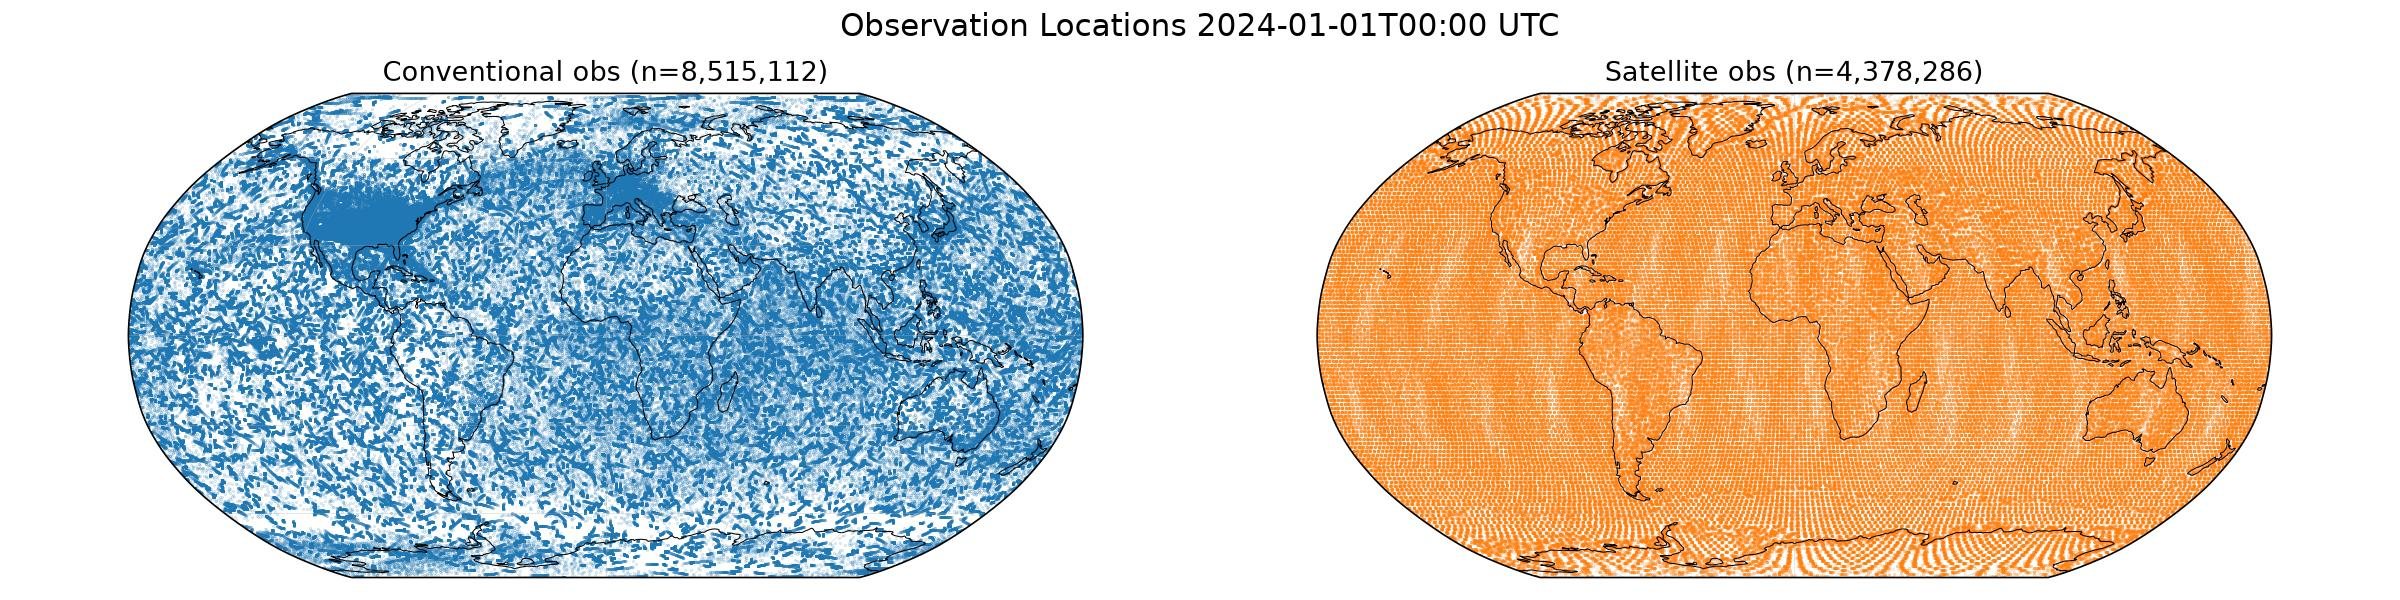

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.close("all")
fig, axes = plt.subplots(
    1,
    2,
    subplot_kw={"projection": ccrs.Robinson()},
    figsize=(16, 4),
)

# Conventional observations
ax = axes[0]
ax.set_global()
ax.coastlines(linewidth=0.5)
ax.gridlines(linewidth=0.3, alpha=0.5)
ax.scatter(
    conv_df["lon"].values[::10],
    conv_df["lat"].values[::10],
    s=0.1,
    alpha=0.3,
    c="tab:blue",
    transform=ccrs.PlateCarree(),
)
ax.set_title(f"Conventional obs (n={len(conv_df):,})", fontsize=13)

# Satellite observations
ax = axes[1]
ax.set_global()
ax.coastlines(linewidth=0.5)
ax.gridlines(linewidth=0.3, alpha=0.5)
ax.scatter(
    sat_df["lon"].values[::10],
    sat_df["lat"].values[::10],
    s=0.1,
    alpha=0.3,
    c="tab:orange",
    transform=ccrs.PlateCarree(),
)
ax.set_title(f"Satellite obs (n={len(sat_df):,})", fontsize=13)
fig.suptitle(
    f"Observation Locations {str(analysis_time[0])[:16]} UTC",
    fontsize=15,
)
plt.tight_layout()
plt.savefig("outputs/22_healda_obs_locations.jpg", dpi=150)


DA models can be called directly for stateless inference or via
`create_generator` for stateful (iterative)
assimilation workflows.  Here we use the direct call API to invoke the model.

HealDA is designed to work with the (-21, 3) hour observation window from the UFS
replay archive using both conventional and satellite observations. However, the DA
model interface is flexible enough to accept different time windows and observation
sources. Below we test three configurations - conventional only, satellite only, and
proper combined - to illustrate the impact each observation type has on the analysis.

In [4]:
torch.manual_seed(42)
result_both = model(conv_obs=conv_df, sat_obs=sat_df)
logger.info(f"Combined analysis shape: {result_both.shape}")


2026-08-12 17:39:23.799 | INFO     | __main__:<module>:3 - Combined analysis shape: (1, 74, 181, 360)


In [5]:
torch.manual_seed(42)
result_sat = model(sat_obs=sat_df)
logger.info(f"Sat-only analysis shape: {result_sat.shape}")


2026-08-12 17:39:25.740 | INFO     | __main__:<module>:3 - Sat-only analysis shape: (1, 74, 181, 360)


In [6]:
torch.manual_seed(42)
result_conv = model(conv_obs=conv_df)
logger.info(f"Conv-only analysis shape: {result_conv.shape}")


2026-08-12 17:39:28.203 | INFO     | __main__:<module>:3 - Conv-only analysis shape: (1, 74, 181, 360)


## Post Processing
Because we loaded the model with ``lat_lon=True`` the output is already on a
regular equiangular lat-lon grid, so no manual regridding is needed.
Compare the three runs for surface temperature (t2m) and geopotential 500 hPa
(z500). Each row shows a different observation configuration.

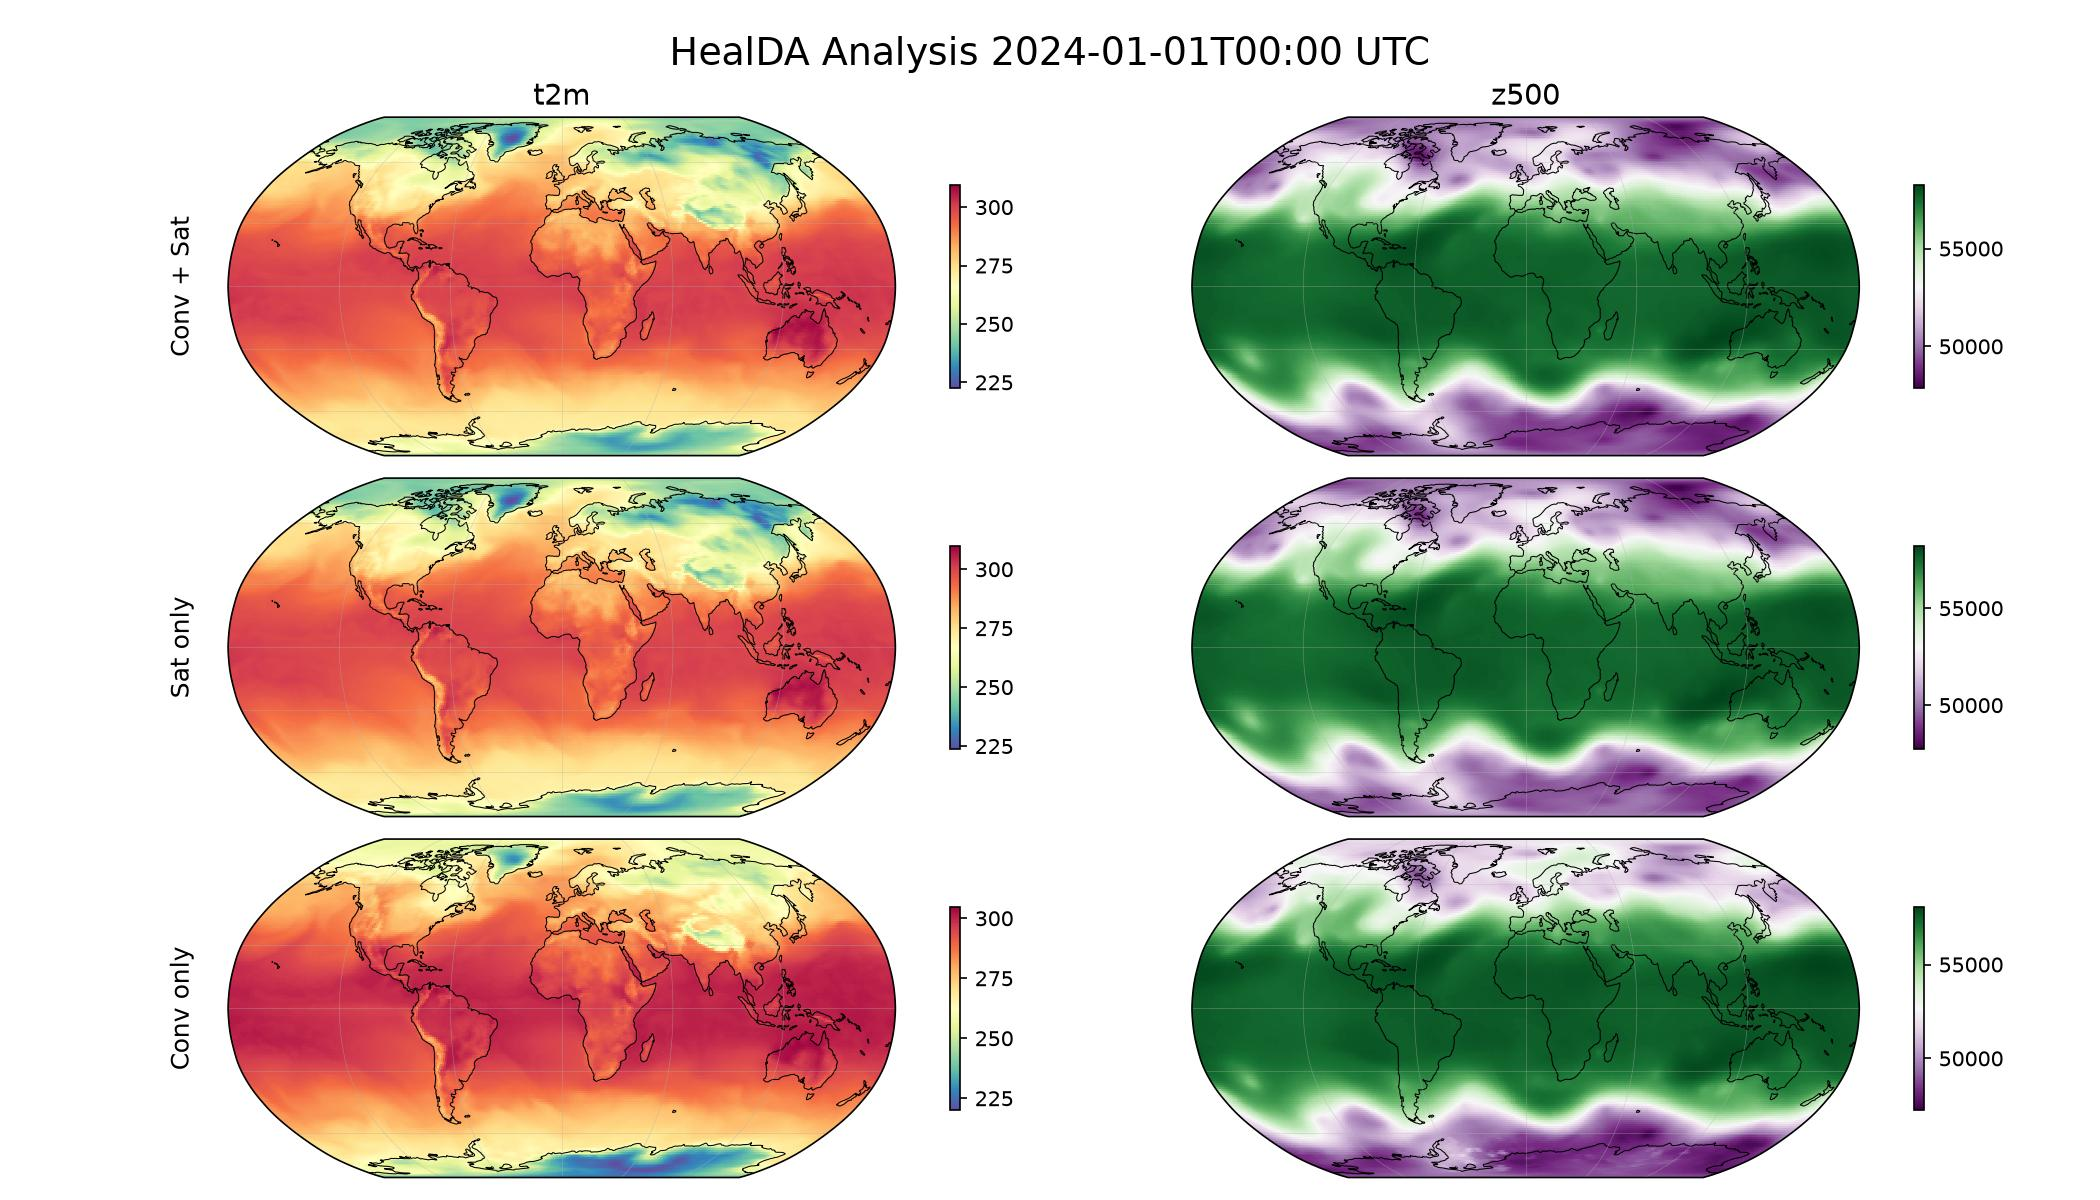

In [7]:
plt.close("all")
plot_vars = ["t2m", "z500"]
titles = ["Conv + Sat", "Sat only", "Conv only"]
results = [result_both, result_sat, result_conv]
projection = ccrs.Robinson()

fig, axes = plt.subplots(
    len(results),
    len(plot_vars),
    subplot_kw={"projection": projection},
    figsize=(14, 8),
)
fig.subplots_adjust(wspace=0.02, hspace=0.08, left=0.1, right=0.9)

lat = results[0].coords["lat"].values
lon = results[0].coords["lon"].values
cmaps = ["Spectral_r", "PRGn"]


def to_numpy(arr):
    """CuPy / Numpy helper function"""
    return arr.get() if hasattr(arr, "get") else arr


for row, (title, da) in enumerate(zip(titles, results)):
    for col, var in enumerate(plot_vars):
        ax = axes[row, col]
        field = to_numpy(da.sel(variable=var).data[0])
        im = ax.pcolormesh(
            lon,
            lat,
            field,
            transform=ccrs.PlateCarree(),
            cmap=cmaps[col],
        )
        ax.coastlines(linewidth=0.5)
        ax.gridlines(linewidth=0.3, alpha=0.5)
        fig.colorbar(im, ax=ax, shrink=0.6)
        if row == 0:
            ax.set_title(var, fontsize=14)
        if col == 0:
            ax.text(
                -0.05,
                0.5,
                title,
                fontsize=12,
                va="bottom",
                ha="center",
                rotation="vertical",
                rotation_mode="anchor",
                transform=ax.transAxes,
            )

fig.suptitle(f"HealDA Analysis {str(analysis_time[0])[:16]} UTC", fontsize=18, y=0.97)
plt.tight_layout()
plt.savefig("outputs/22_healda_analysis.jpg", dpi=150)


## HealDA vs ERA5
Next fetch ERA5 reanalysis at 0.25° resolution from the NCAR archive to compare
against the assimilated fields. HealDA outputs standard Earth2Studio variable
names so we can query ERA5 with the same identifiers. We expect the runs that
are missing an observation source to show larger errors, while the combined run
yields the most accurate global prediction.

In [8]:
era5_ds = NCAR_ERA5()
era5_da = era5_ds(analysis_time, plot_vars)
era5_interp = era5_da.interp(lat=lat, lon=lon, method="nearest")


Fetching NCAR ERA5 data: 100%|██████████| 2/2 [00:00<00:00, 24.02it/s]


In [9]:
diff_titles = ["Conv+Sat - ERA5", "Sat - ERA5", "Conv - ERA5"]
diff_results = [result_both, result_sat, result_conv]
for title, da_pred in zip(diff_titles, diff_results):
    for var in plot_vars:
        field_pred = to_numpy(da_pred.sel(variable=var).data[0])
        field_era5 = to_numpy(era5_interp.sel(variable=var).data[0])
        mae = float(np.abs(field_pred - field_era5).mean())
        logger.info(f"{title} | {var} MAE: {mae:.4f}")


2026-08-12 17:39:59.714 | INFO     | __main__:<module>:8 - Conv+Sat - ERA5 | t2m MAE: 0.7994
2026-08-12 17:39:59.714 | INFO     | __main__:<module>:8 - Conv+Sat - ERA5 | z500 MAE: 51.1967
2026-08-12 17:39:59.715 | INFO     | __main__:<module>:8 - Sat - ERA5 | t2m MAE: 0.8496
2026-08-12 17:39:59.715 | INFO     | __main__:<module>:8 - Sat - ERA5 | z500 MAE: 164.9191
2026-08-12 17:39:59.716 | INFO     | __main__:<module>:8 - Conv - ERA5 | t2m MAE: 4.3306
2026-08-12 17:39:59.716 | INFO     | __main__:<module>:8 - Conv - ERA5 | z500 MAE: 570.9084


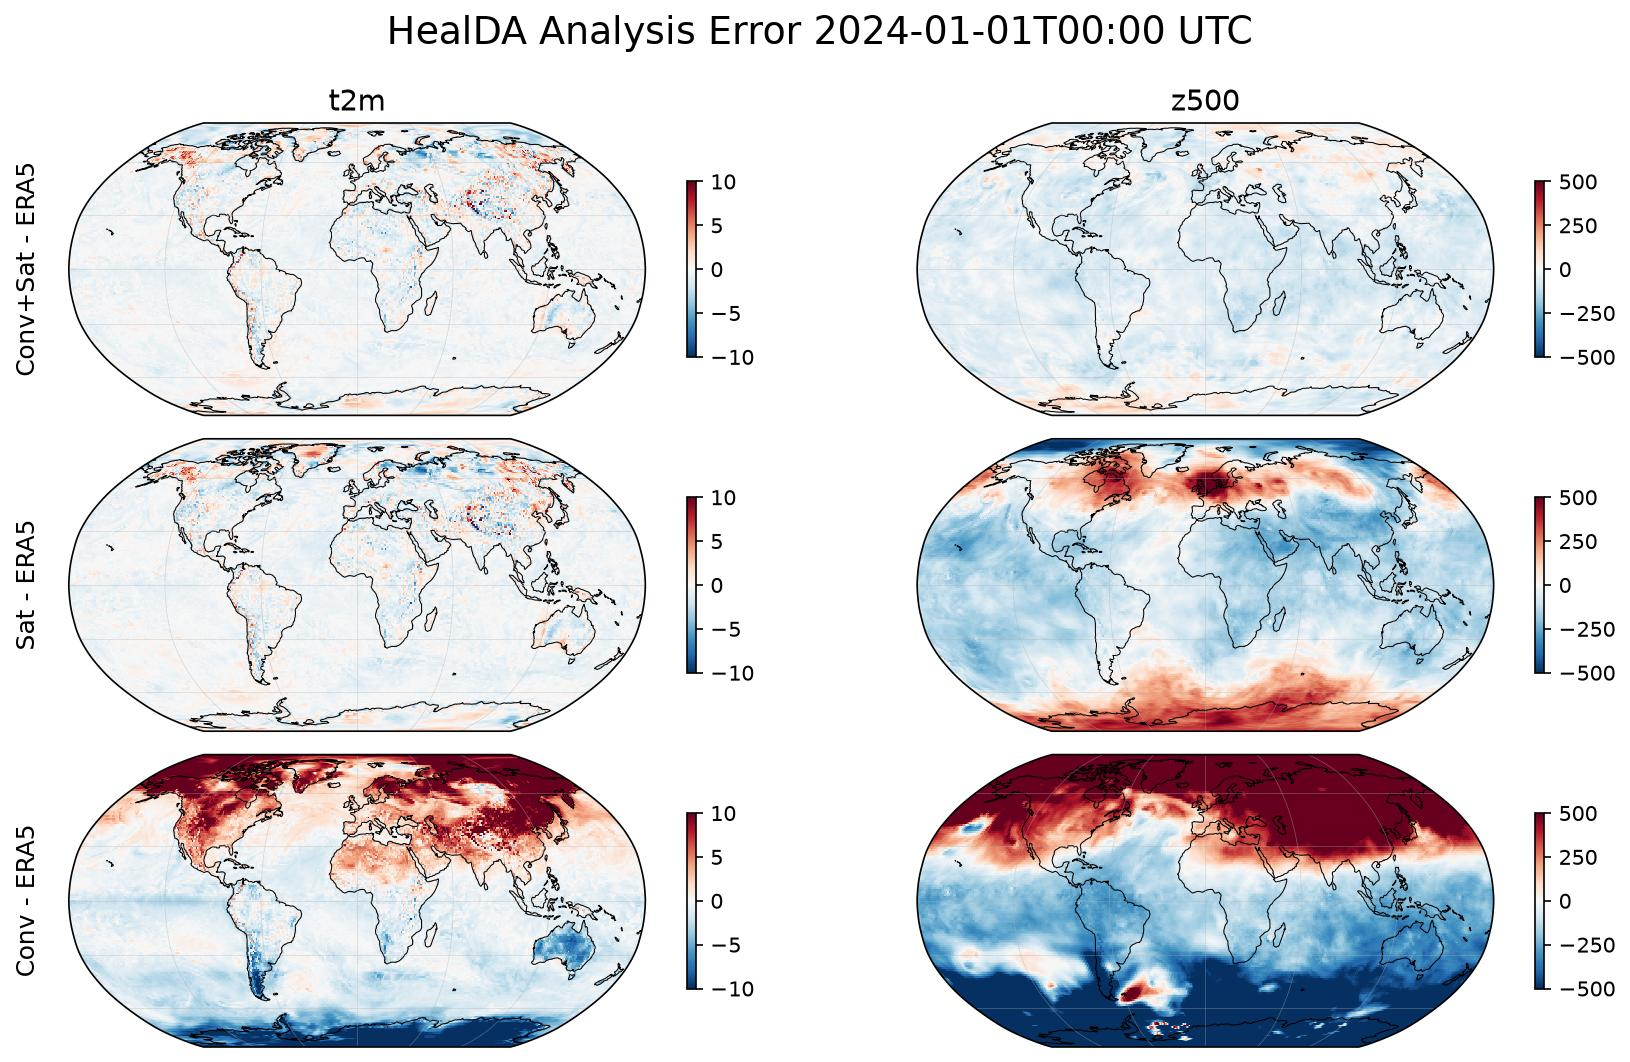

In [10]:
plt.close("all")

diff_ranges = {"t2m": (-10, 10), "z500": (-500, 500)}
fig, axes = plt.subplots(
    len(diff_results),
    len(plot_vars),
    subplot_kw={"projection": projection},
    figsize=(14, 8),
)
fig.subplots_adjust(wspace=0.02, hspace=0.08, left=0.1, right=0.9)

for row, (title, da_pred) in enumerate(zip(diff_titles, diff_results)):
    for col, var in enumerate(plot_vars):
        ax = axes[row, col]
        field_pred = to_numpy(da_pred.sel(variable=var).data[0])
        field_era5 = to_numpy(era5_interp.sel(variable=var).data[0])
        diff = field_pred - field_era5
        im = ax.pcolormesh(
            lon,
            lat,
            diff,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=diff_ranges[var][0],
            vmax=diff_ranges[var][1],
        )
        ax.coastlines(linewidth=0.5)
        ax.gridlines(linewidth=0.3, alpha=0.5)
        fig.colorbar(im, ax=ax, shrink=0.6)
        if row == 0:
            ax.set_title(var, fontsize=14)
        if col == 0:
            bbox = ax.get_position()
            ax.text(
                -0.05,
                0.5,
                title,
                fontsize=12,
                va="bottom",
                ha="center",
                rotation="vertical",
                rotation_mode="anchor",
                transform=ax.transAxes,
            )

fig.suptitle(
    f"HealDA Analysis Error {str(analysis_time[0])[:16]} UTC",
    fontsize=18,
    y=0.97,
)
plt.savefig("outputs/22_healda_differences.jpg", dpi=150, bbox_inches="tight")
